## Pupil Gluing Characterisation 🖌️ WITH flight model!

This notebook:
1. Calculates the Zernike coefficients on two separate plates (one with LC toliman pupil)
2. Calculates the Zernike coefficients on the glued stack

Existing system aberrations are loaded and can be calculated using System_Aberrations.ipynb.

________________________________________________________________________________________________
**NOTE (on data orientation)**: When modelling dLux layers (aberrated apertures, transmissive layers, etc) - they are orientated w.r.t wavefront POV in direction of propagation. In our setup, the data collected has two orientation flips:
1. BFS-U3-200S6M flips image upside down from propagation direction POV (and stores it like this too)
2. The pupil plane is focused by a second OAP which reflects propgagtion direction and in-turn flips left-right (and it stores it like this too)

i.e. total effect is that data is flipped about origin.
________________________________________________________________________________________________

In [1]:
import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dLT

import jax.numpy as jnp
import numpy as np
import jax.random as jr
import jax.scipy as jsp
from jax import vmap  
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_disable_jit', False)


import zodiax as zdx
import optax
from tqdm.notebook import tqdm
# from tqdm import tqdm

from skimage.io import imread
from skimage.filters import window
import skimage as ski
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm
import matplotlib.colors as mcolors

from src.PhaseRetrieval import OptimManager, JointOptimManager, PointSource, TransmissiveLayer, BasisLayer
from src.uv import dummy_splodge_mask, compute_complex_vis, UVComponents

import os
import pickle


import matplotlib as mpl
inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
bwr = mpl.colormaps["bwr"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
bwr.set_bad("k", 0.5)
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'upper' # true reading of array
plt.rcParams['figure.dpi'] = 72
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15

data_dir = "/import/morgana2/gpir9156/toliman/"


In [2]:
print(jax.lib.xla_bridge.get_backend().platform)

cpu


/tmp/ipykernel_2407881/582351387.py:1: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(jax.lib.xla_bridge.get_backend().platform)


In [3]:
# ------- Physical Parameters ---------------------------------------------------------------------#
aperture_npix = 512           # Number of pixels across the aperture
aperture_diameter = 122e-3    # (m) slightly smaller for mask cap
spider_width = 20e-3          # Spider width (m)
spider_angle =270             # Spider angle (degrees), clockwise, 0 is spider pointing vertically up
coords = dlu.pixel_coords(npixels=aperture_npix, diameter=aperture_diameter)
circle = dlu.circle(coords=coords, radius=aperture_diameter/2) 

# Observations wavelengths (bandpass of 530-640nm)
red_laser_wl =  635e-09  # for laser data
green_laser_wl = 520e-09  # for laser data
wf_npixels = aperture_npix  # Number of pixels across the wavefront
wf_diam = aperture_diameter             # Diameter of initial wavefront to propagate wavefront (m)

# Detector parameters (BFS-U3-200S6-BD)
BFS_px_sep = 2.4e-6 *1e3        # pixel separation (mm)
f_det = 1338 # 1300#1350                    # Focal length from OAP2 to detector (mm) 
px_ang_sep = 2*np.arctan( (BFS_px_sep/2)/f_det ) # angular sep between pixels (rad)

# Simulated Detector
psf_npix = 40                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)             # half window sz of cropped data
oversample = 1                 # Oversampling factor for the PSF
psf_pixel_scale = dlu.rad2arcsec(px_ang_sep) # arcsec (to match detector plate scale) 80e-4 

# loading in psf pixel scale and det aberrations found in System_Aberrations.ipynb
f_aberr = "data/spider/retrieval_results/18_03_2026/mcmc_system_coeffs_dict.pkl"

syst_noll = jnp.arange(4, 16) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
# syst_coeffs = pickle.load(open(f_aberr, "rb"))["value"]
stats_dict = pickle.load(open(f_aberr, "rb"))
syst_coeffs=[]
for noll_idx in syst_noll:
    syst_coeffs.append(stats_dict["Noll "+str(noll_idx)]["mean"])

syst_coeffs = jnp.array(syst_coeffs)    
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))
psf_pixel_scale = stats_dict["Px Scale 0"]["mean"] # arcsec
print("Using detector pixel scale of {:.3f} arcsec".format(psf_pixel_scale))


System Coefficients (noll [ 4  5  6  7  8  9 10 11 12 13 14 15]): [-3.52132367e-08  3.65458685e-10  2.32825607e-08  3.30630514e-09
  4.35772934e-09 -1.57253073e-08 -1.48399061e-09  4.46220781e-08
  3.21394627e-09 -4.72026754e-09 -1.01040489e-08  8.94313146e-09]
Using detector pixel scale of 0.369 arcsec


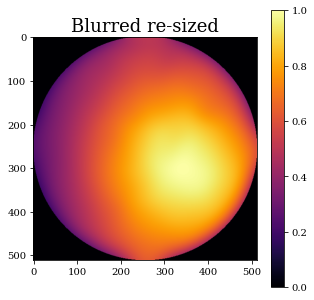

In [4]:
intensity_dist = jnp.load("/import/morgana1/snert/gpir9156/toliman/intensity/26_01_09.npy")
plt.figure(figsize=(5,5))
plt.title("Blurred re-sized")
plt.imshow(intensity_dist)
plt.colorbar()

/import/morgana2/gpir9156/anaconda3/envs/toliman_dp_design/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:5821: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  return array(a, dtype=dtype, copy=bool(copy), order=order, device=device)


Text(0.5, 1.0, 'Spider 180')

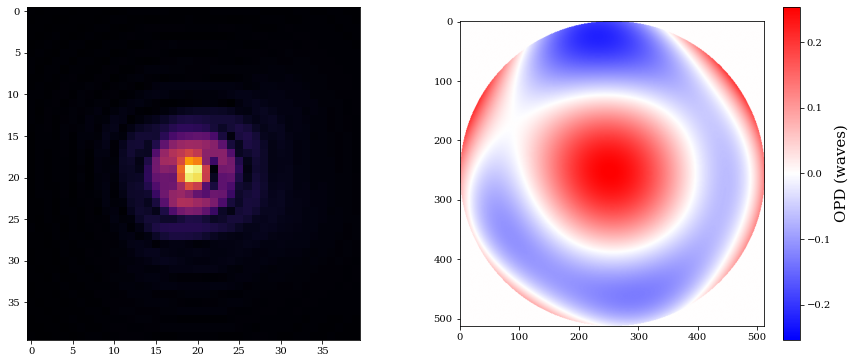

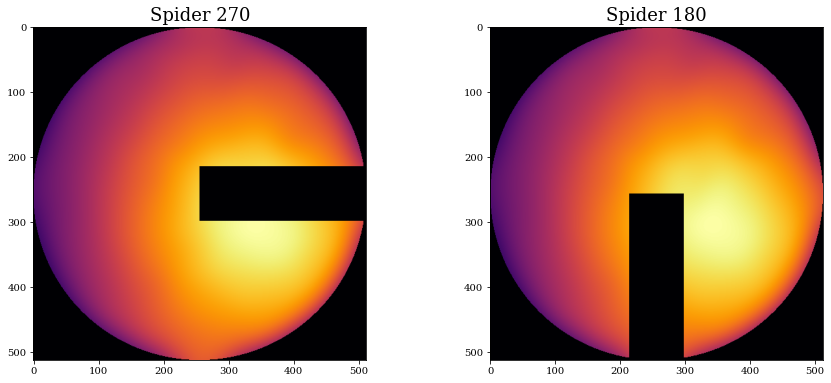

In [5]:
# Zernike aberrations
zernike_indicies = jnp.arange(4, 21) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)

# Using PointSources instead of single PointSource object to overcome float grad issue when solving for flux
# green_src = dl.PointSources(wavelengths=[green_laser_wl], flux =jnp.asarray([1e8],dtype=float))
# red_src = dl.PointSources(wavelengths=[red_laser_wl], flux =jnp.asarray([1e8],dtype=float))
green_src = PointSource(wavelengths=[green_laser_wl], logflux =jnp.asarray([9],dtype=float))
red_src = PointSource(wavelengths=[red_laser_wl], logflux =jnp.asarray([13],dtype=float))

spider_angles = [270, 180] #0deg is spider pointing vertically up, rotates CW from 0deg
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', TransmissiveLayer(transmission=transmission, normalise=False)), #rotable spider
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]

    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]
# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = jnp.flip(optics.propagate_mono(green_laser_wl))
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(psf**0.5)
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd/red_laser_wl, norm=CenteredNorm(), cmap="bwr")
plt.colorbar(label="OPD (waves)")

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(optics_sp270.spider.transmission*optics_sp270.intensity.transmission)
plt.title("Spider 270")
plt.subplot(1,2,2)
plt.imshow(optics_sp180.spider.transmission*optics_sp180.intensity.transmission)
plt.title("Spider 180")

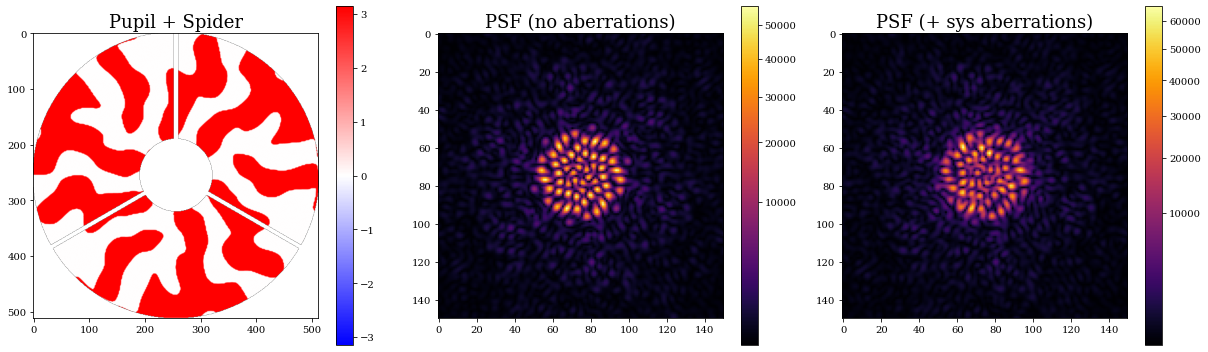

In [26]:
# toliman pupil 
mask_path = "diffractive_pupil.npy"
mask = np.load(mask_path)
mask = resize(mask, (aperture_npix,aperture_npix))
mask_layer = BasisLayer(basis=np.array([mask]), coefficients=np.array([np.pi]), as_phase=True,rotation=0*np.pi/180) # rotating basis layer
tol_psf_npix = 150

zernike_indices = np.arange(4,16)
op_sys = dLT.TolimanOpticalSystem(        
        wf_npixels=mask.shape[0],
        psf_npixels=tol_psf_npix,
        oversample=1,
        psf_pixel_scale=psf_pixel_scale,
        mask=mask_layer,
        noll_indices=zernike_indices,
        )

# replace spider with one that rotates
rot_spider_layer = ('spider', TransmissiveLayer(transmission=op_sys.aperture.transmission))

# separate system coeffs
sys_layer = ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=jnp.zeros((syst_basis.shape[0],)), normalise=False))

# separate plate coeffs (for cleanliness)
plate_layer = ('plate', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False))

op_sys = op_sys.remove_layer("aperture")
op_sys = op_sys.insert_layer(plate_layer, index=0)
op_sys = op_sys.insert_layer(rot_spider_layer, index=0)
op_sys = op_sys.insert_layer(sys_layer, index=0)

op_sys_aberr = op_sys.set("SystemAberrations.coefficients", syst_coeffs)

# Combined system
tol_tel = dl.Telescope(op_sys, ('source', red_src))
tol_tel_sys = dl.Telescope(op_sys_aberr, ('source', red_src))

%matplotlib inline
psf = tol_tel.model()
psf_norm = PowerNorm(gamma=0.5)
pupil_basis = tol_tel.pupil.eval_basis()
spider = tol_tel.spider.transmission

plt.figure(figsize=(17,5))
plt.subplot(1,3,1)
nan_spider = jnp.where(spider==0, jnp.nan, 1)
plt.imshow(pupil_basis*nan_spider, norm=CenteredNorm(), cmap='bwr')
plt.title("Pupil + Spider")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(psf,norm=psf_norm)
plt.title("PSF (no aberrations)")
plt.colorbar()
plt.subplot(1,3,3)
psf = tol_tel_sys.model()
psf_norm = PowerNorm(gamma=0.5)
plt.imshow(psf,norm=psf_norm)
plt.title("PSF (+ sys aberrations)")
plt.colorbar()
plt.tight_layout()

### Load in single plate data
SiO2 printed plate

In [16]:
save_dir = "data/non_glued/18_03_2026_fm/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

plate_name = "lc_plate"

In [17]:
img_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "non_glued/18_03_2026_flightmodel/18_03_2026_red_fullframe.npy",
    "non_glued/18_03_2026_flightmodel/18_03_2026_green_fullframe.npy",
    
]
labels = [
    # "0deg_green",
    # "90deg_green",
    "red",
    "green",
]
bckgnd_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#3_0deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#3_90deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
]


imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck

n_frames = 5   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)


In [18]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1,3])

preproc_imgs = []
img_masks = []
for frame_n in frames_i:
    data_r = imgs[0][frame_n,:,:] 
    data_g = imgs[1][frame_n,:,:]

    data_list = [data_r, data_g]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        scaled_data = data # inverse det model stuff - don't think necessary but maps exist
        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-tol_psf_npix//2:psf_center_idx[0]+tol_psf_npix//2,
                                    psf_center_idx[1]-tol_psf_npix//2:psf_center_idx[1]+tol_psf_npix//2]
        masks.append(m[psf_center_idx[0]-tol_psf_npix//2:psf_center_idx[0]+tol_psf_npix//2,
                                    psf_center_idx[1]-tol_psf_npix//2:psf_center_idx[1]+tol_psf_npix//2])
        
        scaled_data_list.append(scaled_data)

    preproc_imgs.append(scaled_data_list)
    img_masks.append(masks)

preproc_imgs = jnp.asarray(preproc_imgs)
img_masks = jnp.asarray(img_masks)


In [27]:
op_sys_aberr

TolimanOpticalSystem(
  wf_npixels=512,
  diameter=0.125,
  layers={
    'SystemAberrations':
    BasisOptic(
      basis=f64[12,512,512],
      coefficients=f64[12],
      as_phase=False,
      transmission=None,
      normalise=False
    ),
    'spider':
    TransmissiveLayer(
      transmission=f64[512,512],
      normalise=False,
      rotation=f64[1](numpy)
    ),
    'plate':
    BasisOptic(
      basis=f64[17,512,512],
      coefficients=f64[17],
      as_phase=False,
      transmission=None,
      normalise=False
    ),
    'pupil':
    BasisLayer(
      basis=f64[1,512,512],
      coefficients=f64[1],
      as_phase=True,
      rotation=0.0
    )
  },
  psf_npixels=150,
  oversample=1,
  psf_pixel_scale=0.36946258897994305
)

In [ ]:
plt.figure(figsize=(11,5))
plt.suptitle("Eg frame")
plt.subplot(1,2,1)
plt.imshow(preproc_imgs[0][0], norm=PowerNorm(gamma=0.5))
plt.title("red")
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(preproc_imgs[0][4], norm=PowerNorm(gamma=0.5))
plt.title("green")
plt.colorbar()

# Models
tol_tel_red = dl.Telescope(op_sys_aberr, 
                             ('source', PointSource(wavelengths=[green_laser_wl], logflux =jnp.asarray([7-jnp.log(0.8)],dtype=float)))
                             )
tol_tel_green = dl.Telescope(op_sys_aberr, 
                             ('source', PointSource(wavelengths=[green_laser_wl], logflux =jnp.asarray([7-jnp.log(0.8)],dtype=float)))
                             )
plt.figure(figsize=(11,5))
plt.suptitle("Model")
plt.subplot(1,2,1)
plt.imshow(tol_tel_red.model(), norm=PowerNorm(gamma=0.5))
plt.title("red")
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(tol_tel_green.model(), norm=PowerNorm(gamma=0.5))
plt.title("green")
plt.colorbar()

#### GD

In [ ]:
# Create models - one per frame of data
configs = [
        # instrument_sp180_r.set("aperture.coefficients", est_coeffs.flatten()),
        # instrument_sp270_r.set("aperture.coefficients", est_coeffs.flatten()), 
        tol_tel_red,
        # tol_tel_green,
        ]
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)

In [ ]:
params = [
    'plate.coefficients',
    'pupil.rotation',
    'spider.rotation', 
    # 'sam18.rotation',
    'source.position',
    'source.flux', 
    # 'psf_pixel_scale',
    # 'intensity.gauss_param',

    ]

optimisers = [
            optax.adam(learning_rate=1e-10),
            optax.adam(learning_rate=1e-4),
            optax.adam(learning_rate=1e-9),
            optax.adam(learning_rate=1e11), 
            # optax.adam(learning_rate=1e-4),
              ]
